In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

In [72]:
df = pd.read_csv(
    "../data/processed/featured_superstore.csv",
    parse_dates=["order_date", "ship_date"]
)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,day_name,week,day,shipping_days,sales_per_unit,profit_per_unit,discount_amount,profit_status,profit_margin,order_value
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Tuesday,45,8,3,130.9800,20.9568,0.000000,Profit,16.00,261.9600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Tuesday,45,8,3,243.9800,73.1940,0.000000,Profit,30.00,731.9400
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Sunday,23,12,4,7.3100,3.4357,0.000000,Profit,47.00,14.6200
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Sunday,41,11,7,191.5155,-76.6062,430.909875,Loss,-40.00,957.5775
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Sunday,41,11,7,11.1840,1.2582,4.473600,Profit,11.25,22.3680


# 1. Which products generated the highest sales? (Top 10)

In [73]:
top10_products  = (df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10).reset_index())
top10_products 

,product_name,sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


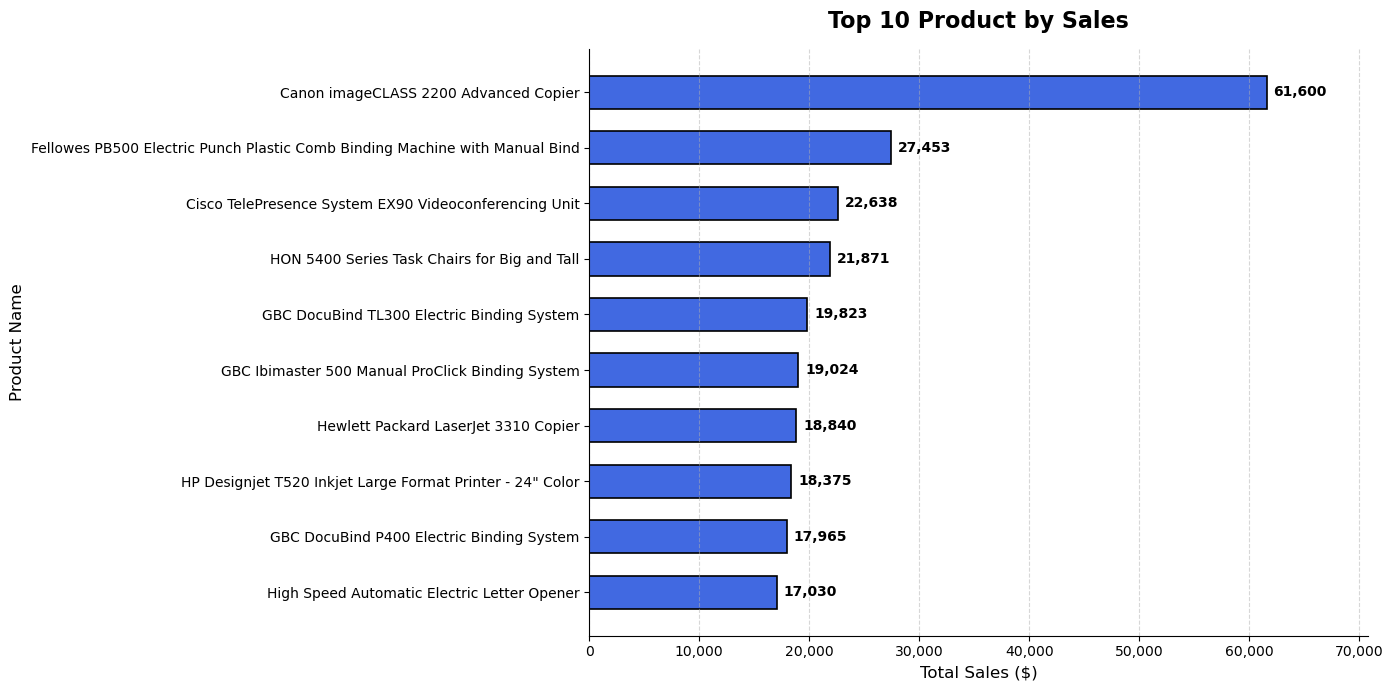

In [74]:
plt.figure(figsize=(14,7))

bars = plt.barh(top10_products["product_name"], top10_products["sales"],
         color="royalblue", edgecolor="black", linewidth=1.2, height=0.6
)

plt.gca().invert_yaxis()

plt.title("Top 10 Product by Sales", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Sales ($)", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, top10_products["sales"].max() * 1.15)

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)


offset = top10_products["sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/top10_products_sales.png",
    dpi=300, bbox_inches="tight"
)

plt.show()

## Insight
- A few products generated the highest sales.
- These products are the company's best-selling products.
- The company should maintain stock availability for these products.

# 2. Which products generated the highest profit? (Top 10)

In [75]:
top10_products_by_profit  = (df.groupby("product_name")["profit"].sum().sort_values(ascending=False).head(10).reset_index())
top10_products_by_profit 

,product_name,profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


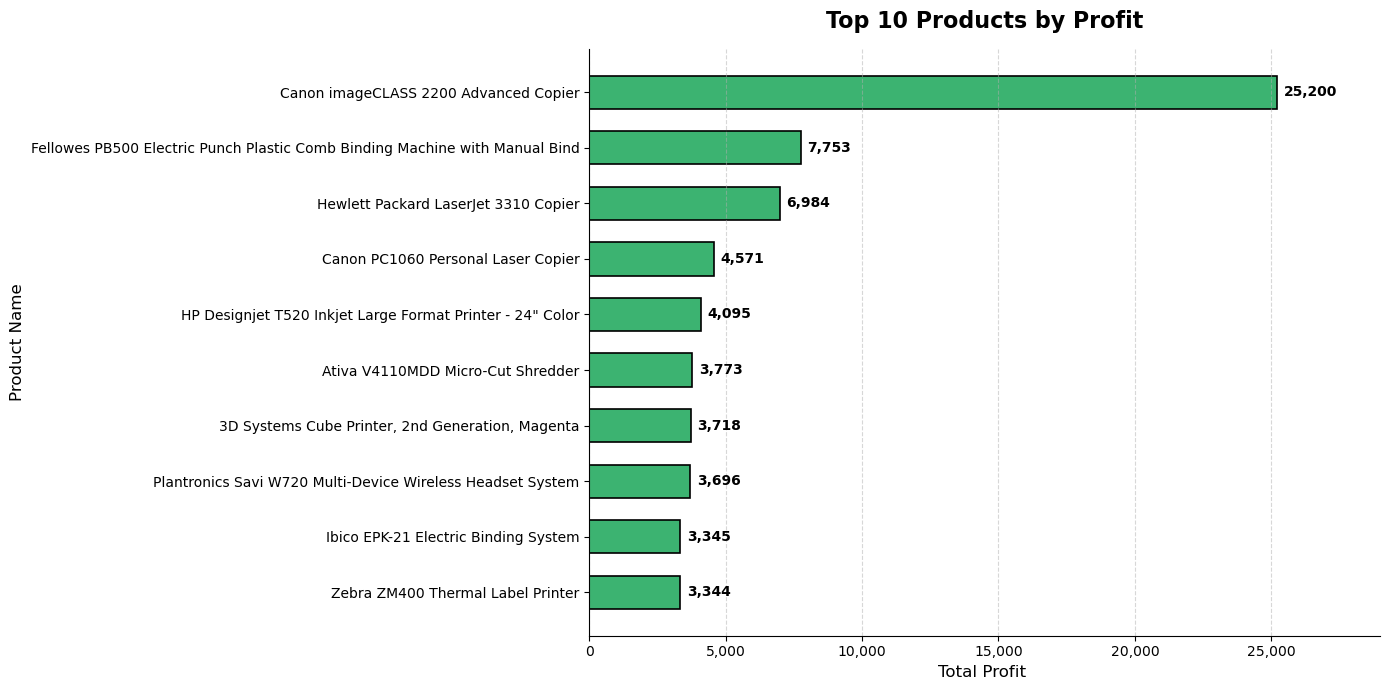

In [76]:

plt.figure(figsize=(14,7))

bars = plt.barh(top10_products_by_profit["product_name"], top10_products_by_profit["profit"],
         color="mediumseagreen", edgecolor="black", linewidth=1.2, height=0.6
)

plt.gca().invert_yaxis()

plt.title("Top 10 Products by Profit", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit ", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.yticks(fontsize=10)

plt.xlim(0, top10_products_by_profit["profit"].max() * 1.15)

# Format x-axis values
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)


offset = top10_products_by_profit["profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/top10_products_profit.png",
    dpi=300, bbox_inches="tight"
)

plt.show()

## Insight
- Some products generate much higher profit than others.
- These products contribute significantly to business growth.
- The company should promote these high-profit products.

# 3. Which products generated the highest losses?(Top 10)

In [77]:
top10_products_loss = (df.groupby("product_name")["profit"].sum().sort_values(ascending=True).head(10).reset_index())
top10_products_loss

,product_name,profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,-1934.3976
5,GBC DocuBind P400 Electric Binding System,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
8,Balt Solid Wood Round Tables,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


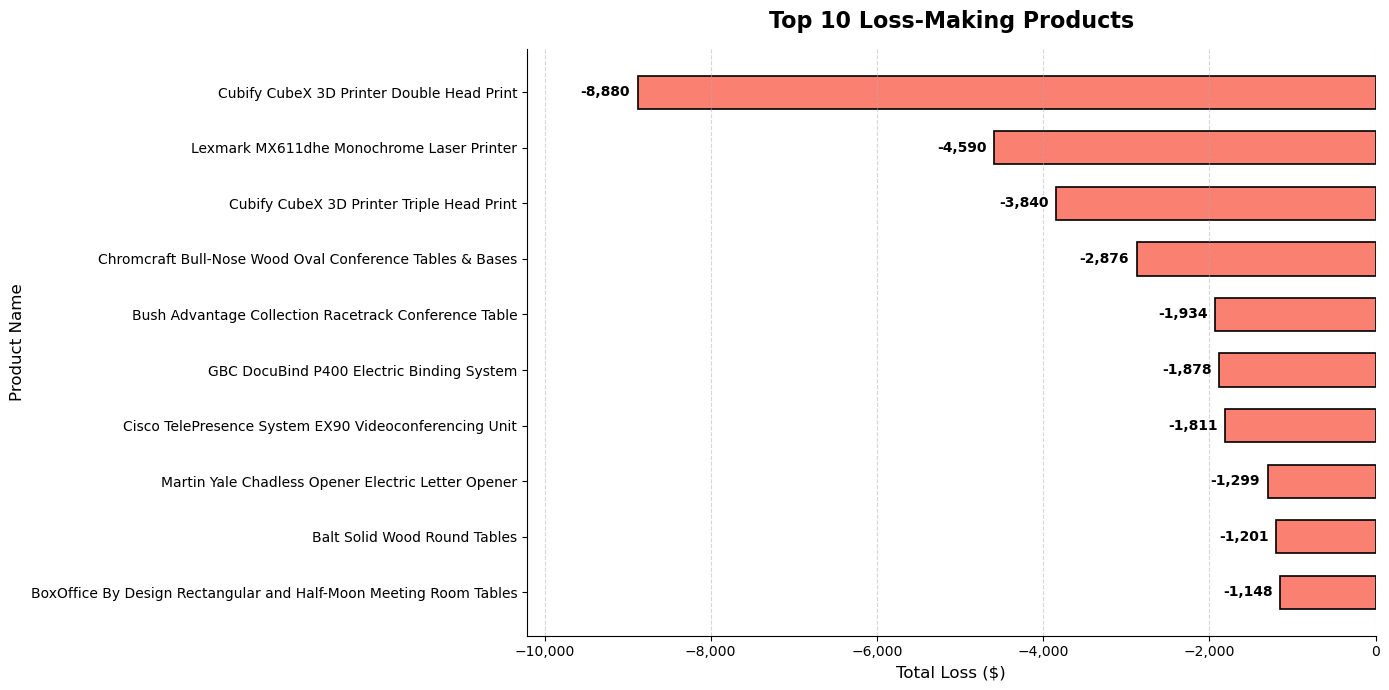

In [78]:
plt.figure(figsize=(14,7))

bars = plt.barh(top10_products_loss["product_name"], top10_products_loss["profit"],
                color="salmon", edgecolor="black", linewidth=1.2, height=0.6
)

# Highest loss at the top
plt.gca().invert_yaxis()

plt.title("Top 10 Loss-Making Products", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Loss ($)", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--",alpha=0.5)

plt.yticks(fontsize=10)

# Negative x-axis
plt.xlim(top10_products_loss["profit"].min() * 1.15, 0)

# Format x-axis values
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

offset = abs(top10_products_loss["profit"].min()) * 0.01

for bar in bars:
    plt.text(
        bar.get_width() - offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="right",
        fontsize=10, fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/top10_loss_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Some products generated negative profit.
- High discounts or high costs may be the reason.
- These products should be reviewed to reduce losses.

# 4. Which products were ordered the most? (Top 10 by Quantity)

In [79]:
top10_products_quantity = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_products_quantity

,product_name,quantity
0,Staples,215
1,Staple envelope,170
2,Easy-staple paper,150
3,Staples in misc. colors,86
4,KI Adjustable-Height Table,74
5,Storex Dura Pro Binders,71
6,Avery Non-Stick Binders,71
7,GBC Premium Transparent Covers with Diagonal L...,67
8,"Situations Contoured Folding Chairs, 4/Set",64
9,Staple-based wall hangings,62


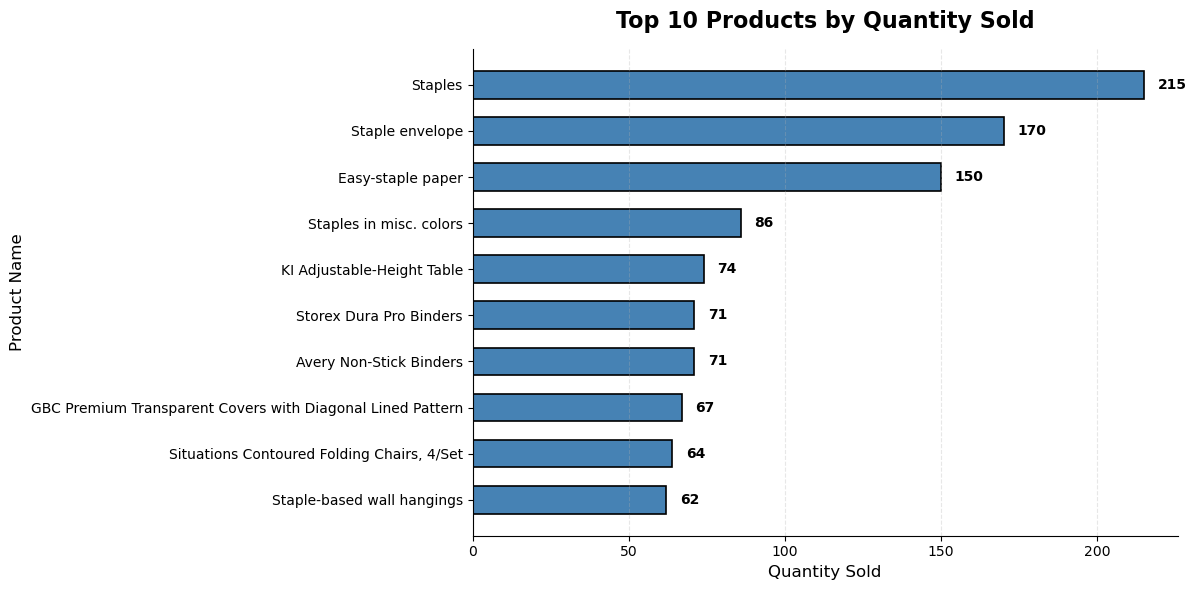

In [80]:

plt.figure(figsize=(12,6))

bars = plt.barh(
    top10_products_quantity["product_name"],
    top10_products_quantity["quantity"],
    color="steelblue",
    edgecolor="black",
    linewidth=1.2,
    height=0.6
)

# Highest quantity at top
plt.gca().invert_yaxis()

plt.title(
    "Top 10 Products by Quantity Sold",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Quantity Sold", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Value Labels
offset = top10_products_quantity["quantity"].max() * 0.02

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Remove Top & Right Border
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/top10_products_by_quantity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- These products were purchased most frequently.
- They are highly demanded by customers.
- The company should ensure these products remain in stock.

# 5. Which sub-category generated the highest average sales?

In [81]:
avg_sales_subcategory = (
    df.groupby("sub_category")["sales"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

avg_sales_subcategory

,sub_category,sales
0,Copiers,2198.941618
1,Machines,1645.553313
2,Tables,648.794771
3,Chairs,532.332420
4,Bookcases,503.859633
5,Phones,371.211534
6,Storage,264.590553
7,Supplies,245.650200
8,Appliances,230.755710
9,Accessories,215.974604


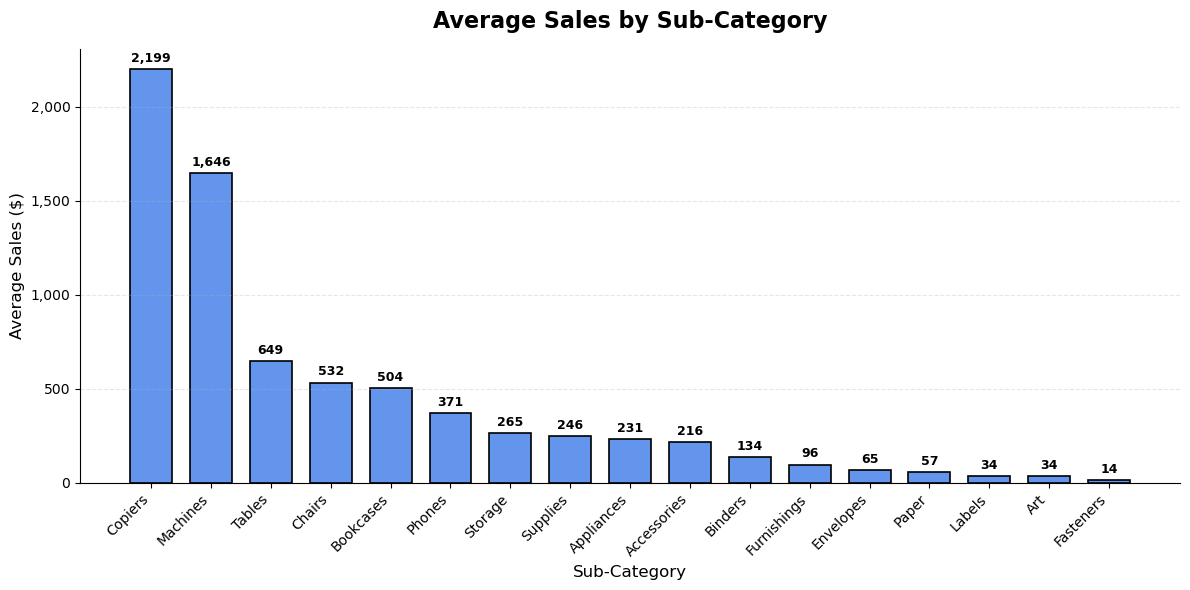

In [82]:

plt.figure(figsize=(12,6))

bars = plt.bar(
    avg_sales_subcategory["sub_category"],
    avg_sales_subcategory["sales"],
    color="cornflowerblue",
    edgecolor="black",
    linewidth=1.2,
    width=0.7
)

plt.title(
    "Average Sales by Sub-Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sub-Category", fontsize=12)
plt.ylabel("Average Sales ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Format Y-axis
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

# Value Labels
offset = avg_sales_subcategory["sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + offset,
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Remove Top & Right Border
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/average_sales_by_subcategory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Some sub-categories have higher average sales than others.
- These sub-categories perform better on average.
- They represent strong revenue opportunities.

# 6. Which sub-category generated the highest average profit?

In [83]:
avg_profit_subcategory = (
    df.groupby("sub_category")["profit"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

avg_profit_subcategory

,sub_category,profit
0,Copiers,817.909190
1,Accessories,54.111788
2,Phones,50.073938
3,Chairs,43.095894
4,Appliances,38.922758
5,Machines,29.432669
6,Envelopes,27.418019
7,Storage,25.152277
8,Paper,24.856620
9,Binders,19.843574


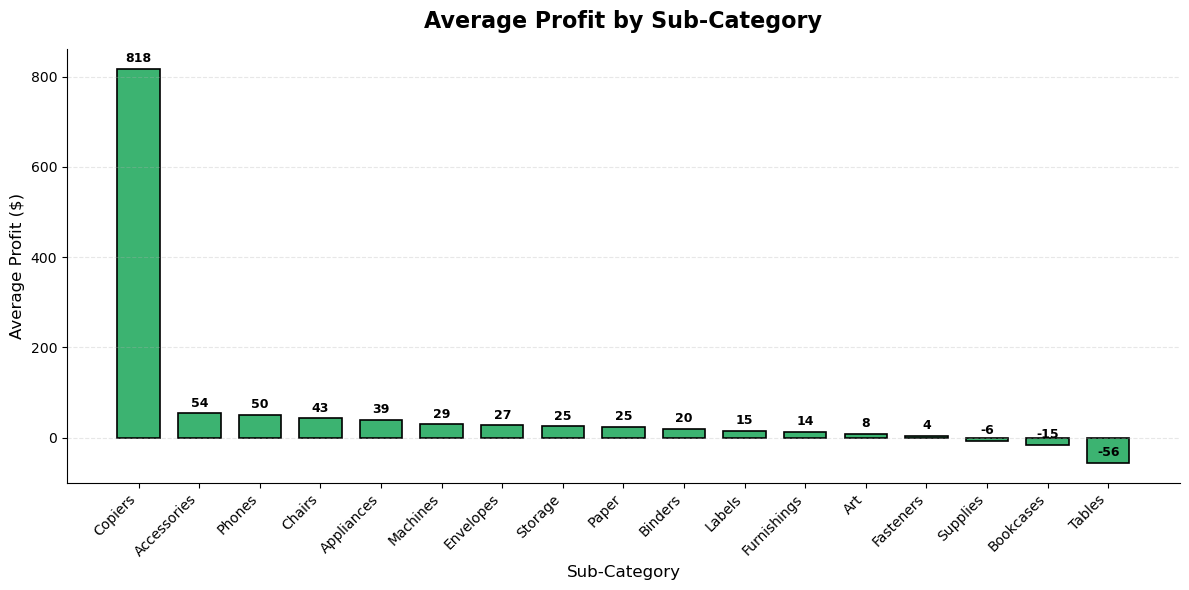

In [84]:

plt.figure(figsize=(12,6))

bars = plt.bar(
    avg_profit_subcategory["sub_category"],
    avg_profit_subcategory["profit"],
    color="mediumseagreen",
    edgecolor="black",
    linewidth=1.2,
    width=0.7
)

plt.title(
    "Average Profit by Sub-Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sub-Category", fontsize=12)
plt.ylabel("Average Profit ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Format Y-axis
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

# Value Labels
offset = avg_profit_subcategory["profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + offset,
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Remove Top & Right Border
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/average_profit_by_subcategory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- The most profitable sub-categories generate higher profit per order.
- These products provide better business returns.
- Marketing efforts can focus on these sub-categories.

# 7. What is the distribution of product sales?

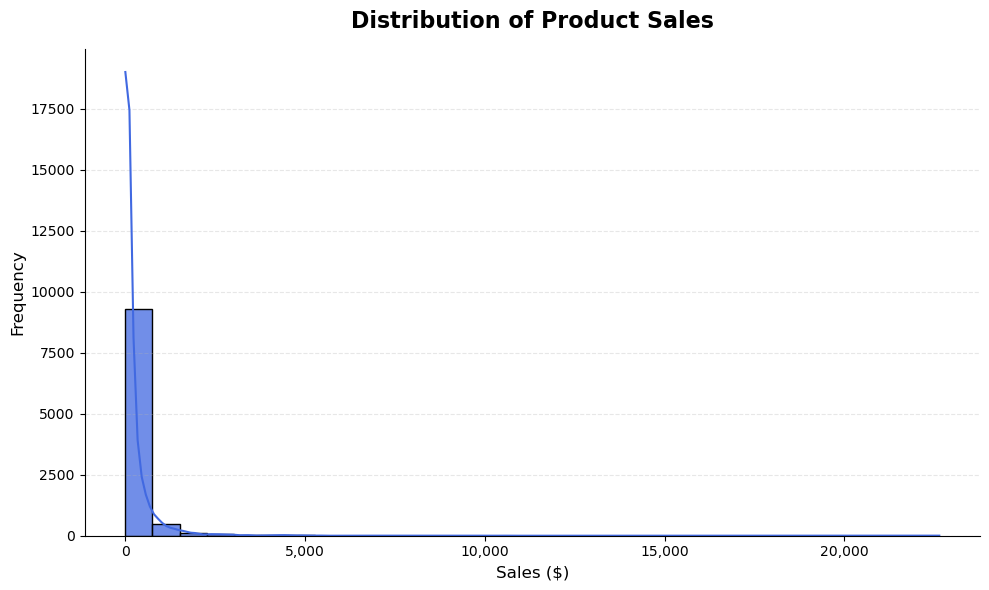

In [85]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="sales",
    bins=30,
    kde=True,
    color="royalblue",
    edgecolor="black",
    alpha=0.75
)

plt.title(
    "Distribution of Product Sales",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sales ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/product_sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Most products have low to medium sales.
- Only a few products generate very high sales.
- This indicates that sales are concentrated in a small number of products.

# 8. What is the relationship between product sales and profit?

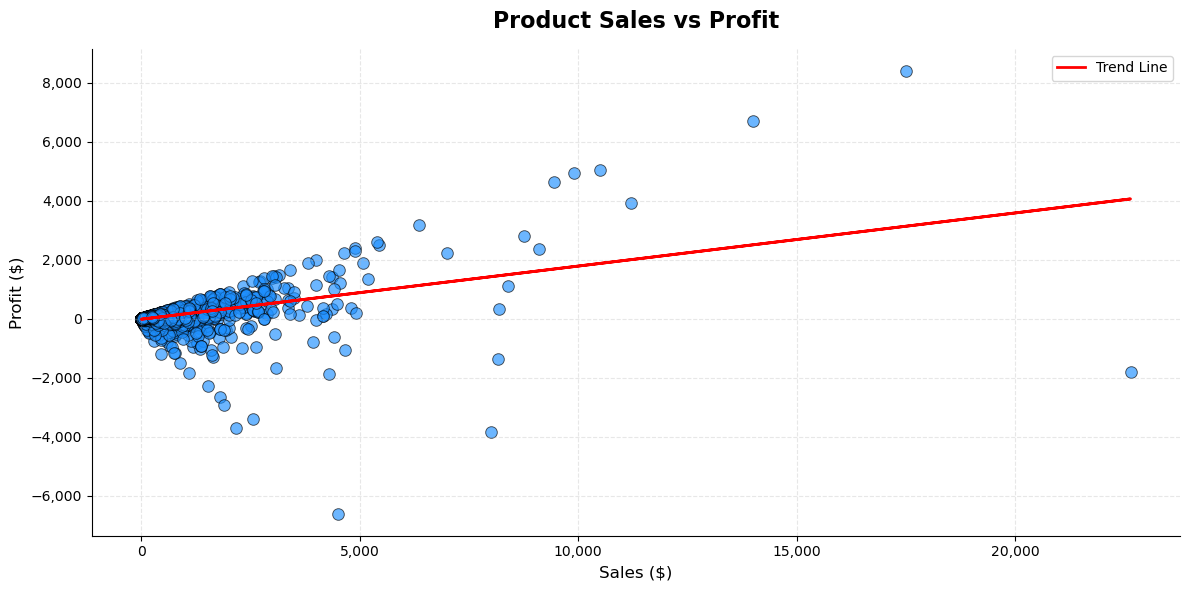

In [86]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit",
    color="dodgerblue",
    edgecolor="black",
    s=70,
    alpha=0.65
)

# Trend Line

z = np.polyfit(df["sales"], df["profit"], 1)
p = np.poly1d(z)

plt.plot(
    df["sales"],
    p(df["sales"]),
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title(
    "Product Sales vs Profit",
    fontsize=16,
    fontweight="bold",
    pad=15

)

plt.xlabel("Sales ($)", fontsize=12)
plt.ylabel("Profit ($)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend()

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/products/product_sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Products with higher sales do not always generate higher profit.
- Some products have high sales but low profit because of discounts or costs.
- Both sales and profit should be considered when evaluating product performance.